# Figure 2

Cleaned: Jan 22, 2025


## NOTE: COLOR OF EDITING EFFICIENCY NEED TO BE CHANGED 

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os
import functools
import upsetplot

warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()

# 2b

In [2]:
CBE_counts = pd.read_csv('counts/og/OG_CBE_COUNTS.txt', sep='\t')
ABE_counts = pd.read_csv('counts/og/OG_ABE_COUNTS.txt', sep='\t')
CBE_counts = CBE_counts[CBE_counts.columns[2:]]
ABE_counts = ABE_counts[ABE_counts.columns[2:]]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[53.11619452 14.31995016]


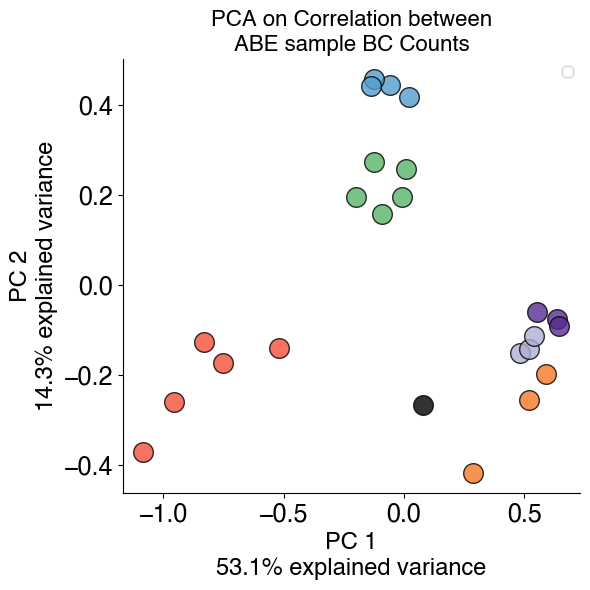

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Xt = pca.fit_transform(ABE_counts.corr(method='spearman'))
fig, ax = plt.subplots(figsize=(6,6))

blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')


blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = [blues[0], blues[2], blues[3], blues[5], greens[1], greens[2], greens[3], greens[4], greens[5],  reds[1], reds[2], reds[3], reds[4], reds[5],
           yellows[1], yellows[2], yellows[3], purples[0], purples[1], purples[2], purples[3], purples[4], purples[5], 'black']

palette = [blues[3], blues[3], blues[3], blues[3], greens[3], greens[3], greens[3], greens[3], greens[3],  reds[3], reds[3], reds[3], reds[3], reds[3],
           yellows[3], yellows[3], yellows[3], purples[2], purples[2], purples[2], purples[5], purples[5], purples[5], 'black']

for i in range(len(Xt)):
    ax.scatter(Xt[i][0], Xt[i][1], edgecolor='black', s=200, alpha=.8,c=palette[i]) #,label=list(ABE_counts.columns)[i])

ax.legend(loc='best')

var = pca.explained_variance_ratio_
print(var*100)
ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% explained variance', fontsize=17)
ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% explained variance', fontsize=17)
#ax.legend(bbox_to_anchor=(1.05, 1.))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=18,)
ax.set_title('PCA on Correlation between\nABE sample BC Counts', fontsize=16)
fig.tight_layout()

# 2c

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[36.03498449 11.14300231]


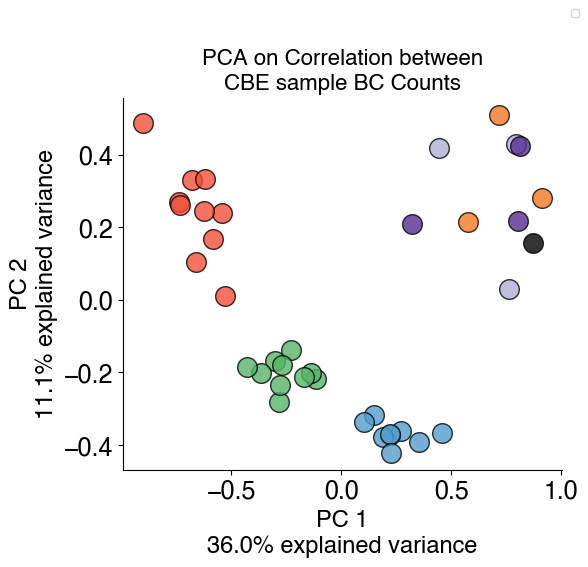

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Xt = pca.fit_transform(CBE_counts.corr(method='spearman'))
fig, ax = plt.subplots(figsize=(6,6))

blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')


blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = [blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], 
           greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3],
           reds[3], reds[3], reds[3], reds[3], reds[3], reds[3],reds[3], reds[3], reds[3], reds[3],
           yellows[3], yellows[3], yellows[3], 
           purples[2], purples[2], purples[2], purples[5], purples[5], purples[5], 
           'black']


for i in range(len(Xt)):
    ax.scatter(Xt[i][0], Xt[i][1], edgecolor='black', s=200, alpha=.8,c=palette[i]) #, label=list(CBE_counts.columns)[i])

ax.legend(loc='best')

var = pca.explained_variance_ratio_
print(var*100)
ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% explained variance', fontsize=17)
ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% explained variance', fontsize=17)
ax.legend(bbox_to_anchor=(1.05, 1.25), fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=18,)
ax.set_title('PCA on Correlation between\nCBE sample BC Counts', fontsize=16)
fig.tight_layout()

# 2d

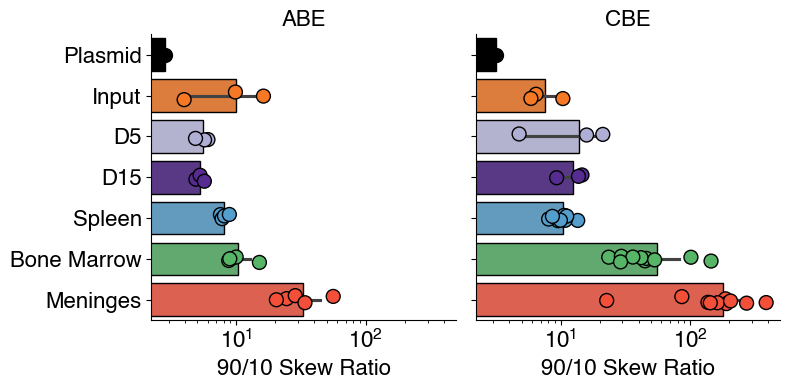

In [6]:
CBE_samps = list(CBE_counts.columns)
ABE_samps = list(ABE_counts.columns)

CBE_skew = []
ABE_skew = []
for i in CBE_samps:
    d = sorted(np.asarray(CBE_counts[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    CBE_skew.append(d[ninety]/d[ten])

for i in ABE_samps:
    d = sorted(np.asarray(ABE_counts[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    ABE_skew.append(d[ninety]/d[ten])

CBE_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [CBE_samps, CBE_skew])))
ABE_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [ABE_samps, ABE_skew])))

ax_dict_CBE = dict(zip(['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6',
       'spleen7', 'spleen8', 'spleen9', 'bonemarrow1', 'bonemarrow2',
       'bonemarrow3', 'bonemarrow4', 'bonemarrow5', 'bonemarrow6',
       'bonemarrow7', 'bonemarrow8', 'bonemarrow9', 'bonemarrow10',
       'meninges1', 'meninges2', 'meninges3', 'meninges4', 'meninges5',
       'meninges6', 'meninges7', 'meninges8', 'meninges9', 'meninges10',
       'input_rep1', 'input_rep2', 'input_rep3', 'd5_rep1', 'd5_rep2',
       'd5_rep3', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'plasmidlib'], 
       [4,4,4,4,4,4,4,4,4,
        5,5,5,5,5,5,5,5,5,5,
        6,6,6,6,6,6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0]))

ax_dict_ABE = dict(zip(['spleen1', 'spleen2', 'spleen3', 'spleen4', 
          'bonemarrow1','bonemarrow2', 'bonemarrow3', 'bonemarrow4', 'bonemarrow5',
            'meninges1','meninges2', 'meninges3', 'meninges4', 'meninges5',
              'input_rep1', 'input_rep2', 'input_rep3',
                'd5_rep1', 'd5_rep2', 'd5_rep3', 
                'd15_rep1','d15_rep2', 'd15_rep3', 
                'plasmidlib'], 
       [4,4,4,4,
        5,5,5,5,5,
        6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0]))

d2 = dict(zip([0,1,2,3,4,5,6],['Plasmid', 'Input','D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

CBE_name = []
ABE_name = []
for i, val in CBE_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_CBE[s]
    s3 = d2[s2]
    CBE_name.append(s3)

for i, val in ABE_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_ABE[s]
    s3 = d2[s2]
    ABE_name.append(s3)

ABE_skew_df['Name'] = ABE_name
CBE_skew_df['Name'] = CBE_name


fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order=['Plasmid', 'Input', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

sns.barplot(data = ABE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
sns.barplot(data = CBE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)

sns.stripplot(data = ABE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
sns.stripplot(data = CBE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_ylabel('')
ax[1].set_ylabel('')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('ABE', fontsize=16)
ax[1].set_title('CBE', fontsize=16)
ax[0].set_xlabel('90/10 Skew Ratio', fontsize=16)
ax[1].set_xlabel('90/10 Skew Ratio', fontsize=16)

fig.tight_layout()

# 2e

In [7]:
MBES = pd.read_csv('MBESv2_CORRECTED.csv')
ABE = MBES[(MBES['Editor']=='ABE') & (MBES['classification']=='targeting guide')]
#CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['legacy']==False) & (MBES['classification']=='targeting guide')]

CBE = MBES[(MBES['Editor']=='CBE') & (MBES['classification']=='targeting guide')]

In [8]:
ABE_raw = os.listdir('crispresso/og/ABE')
CBE_raw = os.listdir('crispresso/og/CBE')

#remove spleen 5 do to almost zero reads
ABE_raw.remove('spleen_rep5_ABE.csv')

#set filters for minimum number of sensor reads
min_sensor_reads = 10

t = []
corr = []
name = []

name_dict = {'meninges':'Meninges', 'spleen':'Spleen', 'bonemarrow':'Bone Marrow', 'd5':'D5', 'd15':'D15', 'plasmidlib':'Plasmid', 'input':'Input'}

for i in ABE_raw:
    g = pd.read_csv(f'crispresso/og/ABE/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
    name.append(name_dict[i.split('_')[0]])

t2 = []
corr2 = []
name2 = []

for i in CBE_raw:
    g = pd.read_csv(f'crispresso/og/CBE/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t2.append(np.average(g2['target_base_edit_perc']))
    corr2.append(np.average(g2['corr_perc']))
    name2.append(name_dict[i.split('_')[0]])

CBE_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name2, t2,])))
CBE_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name2, corr2])))
CBE_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_editing2['Edit Type'] = 'Pure Correct Editing'
CBE_editing = pd.concat((CBE_editing1, CBE_editing2))

ABE_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_editing = pd.concat((ABE_editing1, ABE_editing2))

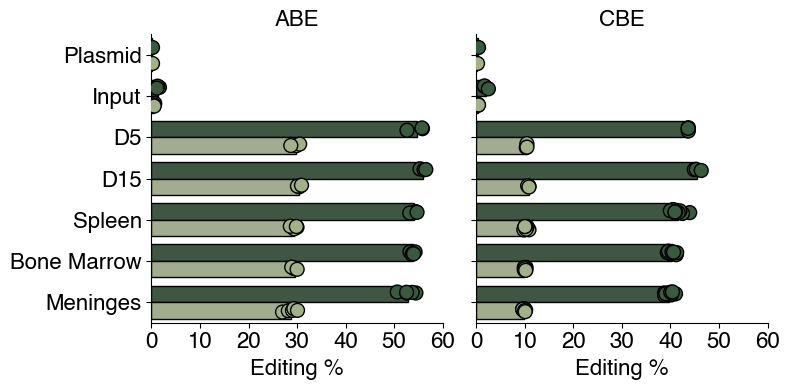

In [9]:
fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

sns.barplot(data = ABE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order)
sns.barplot(data = CBE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'],order=order)#), legend=False)


sns.stripplot(data = ABE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'], order=order, dodge=True, s=10)
sns.stripplot(data = CBE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1], edgecolor='black', linewidth=1, palette = ['#3a5a40', '#a3b18a'],order=order, dodge=True, s=10)#), legend=False)
#sns.stripplot(data = ABE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
#sns.stripplot(data = CBE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)

ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_xticks([0,10,20,30,40,50,60])
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('ABE', fontsize=16)
ax[1].set_title('CBE', fontsize=16)
ax[0].set_xlabel('Editing %', fontsize=16)
ax[1].set_xlabel('Editing %', fontsize=16)
ax[0].legend([],[], frameon=False)
ax[1].legend([],[], frameon=False)

fig.tight_layout()
fig.savefig('figures/fig2e.pdf')

# 2f

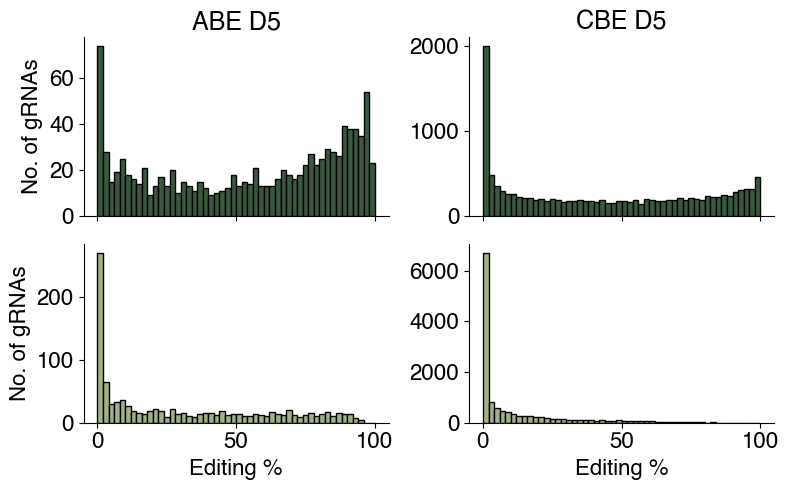

In [10]:
d5_ABE = pd.read_csv('MLE/og/ABE/d5_ABE_MLE.csv').rename(columns = {'Guide_ID':'gRNA_id'})
d5_CBE = pd.read_csv('MLE/og/CBE/d5_CBE_MLE.csv').rename(columns = {'Guide_ID':'gRNA_id'})

ABE = MBES[(MBES['Editor']=='ABE') & (MBES['classification']=='targeting guide')]
CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['classification']=='targeting guide')]

ABE_edits = pd.merge(d5_ABE, ABE, on='gRNA_id')
CBE_edits = pd.merge(d5_CBE, CBE_non_leg, on='gRNA_id')

fig, ax = plt.subplots(2,2,figsize=(8,5), sharex=True, sharey=False)

ax[0][0].hist(ABE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color='#3a5a40', edgecolor='black')
ax[1][0].hist(ABE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='#a3b18a', edgecolor='black')

ax[0][1].hist(CBE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), color='#3a5a40', linewidth=1, edgecolor='black')
ax[1][1].hist(CBE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='#a3b18a', edgecolor='black')
ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)
ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)
ax[0][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)
ax[1][0].set_xlabel('Editing %', fontsize=16)

ax[0][0].set_title('ABE D5', fontsize=18)
ax[0][1].set_title('CBE D5', fontsize=18)

fig.tight_layout()
fig.savefig('figures/fig2f.pdf')

# 2g-h

In [15]:
ABE_LFC_FDR = pd.read_csv('LFC-FDR/og/ABE_LFC_FDR_df_og.csv')
CBE_LFC_FDR = pd.read_csv('LFC-FDR/og/CBE_LFC_FDR_df_og.csv')

cosmic = pd.read_csv('source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')

t_dict = {'TSG':'TSG', 'TSG, fusion':'TSG', 'Undefined':'Undefined', 'fusion':'Undefined', 'oncogene':'Oncogene',
       'oncogene, TSG':'Oncogene/TSG', 'oncogene, TSG, fusion':'Oncogene/TSG', 'oncogene, fusion': 'Oncogene'}

gene_type = []
for i, val in ABE_LFC_FDR.iterrows():
    v = val['gene_name_h']
    subset = cosmic[cosmic['Gene Symbol']==v]
    if len(subset)==0:
        gene_type.append('Undefined')
    else:
        v2 = subset['Role in Cancer'].values[0]

        gene_type.append(t_dict[v2])

ABE_LFC_FDR['Role in Cancer']=gene_type

gene_type = []
for i, val in CBE_LFC_FDR.iterrows():
    v = val['gene_name_h']
    subset = cosmic[cosmic['Gene Symbol']==v]
    if len(subset)==0:
        gene_type.append('Undefined')
    else:
        v2 = subset['Role in Cancer'].values[0]

        gene_type.append(t_dict[v2])

CBE_LFC_FDR['Role in Cancer']=gene_type

d15
1 Pik3r3 D11G tab:grey
2 Daxx N274S tab:purple
3 Syk N451S tab:red
4 Raf1 R391G tab:red
5 Myc T73A tab:red
6 Ret K809E tab:red
7 Erbb3 Q807R tab:red
8 Keap1 Y33H tab:blue
9 Rbm10 H777R tab:blue
10 Arid5b K1026E tab:grey
786 Trp53 C138R tab:purple
787 Vhl L124P tab:blue
788 Ctnnb1 S45P tab:red
789 Braf K638E tab:red
790 Ctnnb1 S45P tab:red
791 Ctcf C384R tab:blue
792 Map2k1 F53L tab:red
793 Ctnnb1 T41A tab:red
794 Ezh2 Non-coding tab:purple
795 Vhl N44S tab:blue
1. Pik3r3 D11G
2. Daxx N274S
3. Syk N451S
4. Raf1 R391G
5. Myc T73A
6. Ret K809E
7. Erbb3 Q807R
8. Keap1 Y33H
9. Rbm10 H777R
10. Arid5b K1026E
786. Trp53 C138R
787. Vhl L124P
788. Ctnnb1 S45P
789. Braf K638E
790. Ctnnb1 S45P
791. Ctcf C384R
792. Map2k1 F53L
793. Ctnnb1 T41A
794. Ezh2 Non-coding
795. Vhl N44S
spleen
1 Ctnnb1 S45P tab:red
2 Ercc2 T484A tab:blue
3 Nfe2 Q286R tab:grey
4 Ep300 H350R tab:blue
5 Syk N451S tab:red
6 Raf1 R391G tab:red
7 Gata3 H281R tab:purple
8 Smo I160V tab:red
9 Keap1 H311R tab:blue
10 Myd88 M219T

Text(0.5, 1.0, 'Meninges')

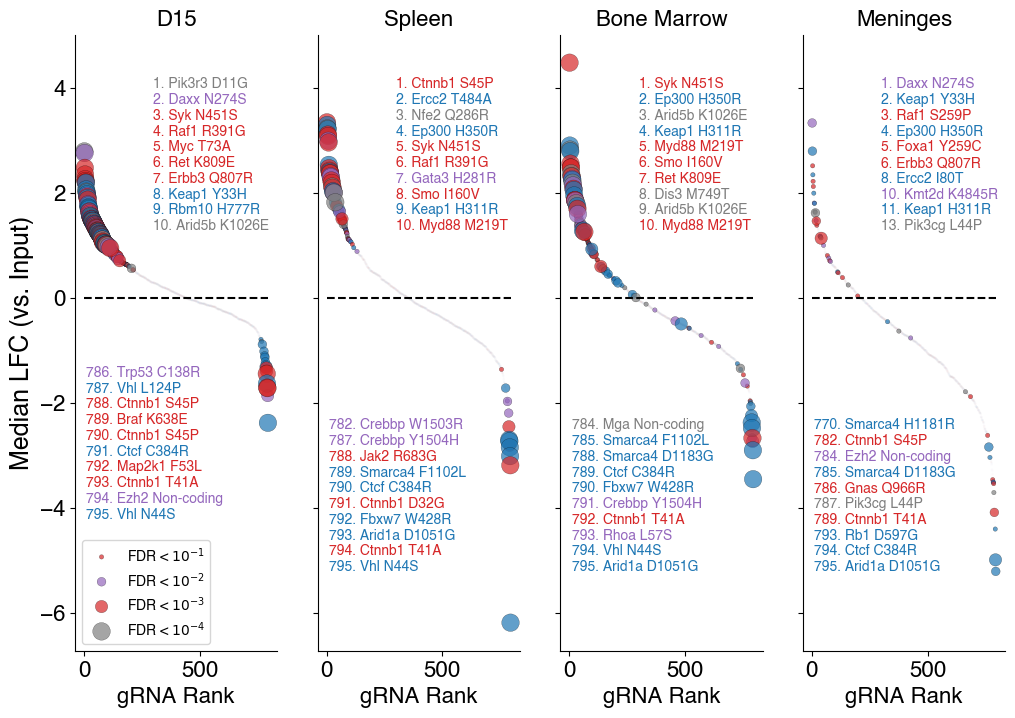

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects

min_edit = 20
FDR_cutoff = .1
min_input_counts = 2

ABE_targ = ABE_LFC_FDR[(ABE_LFC_FDR['classification']=='targeting guide')& (ABE_LFC_FDR['target_base_edit_perc']>=min_edit) & (ABE_LFC_FDR['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]

color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]



    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]
      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) &(cc2[f'FDR_{val}']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}']<FDR_cutoff]
    top = cc3[:10]
    bottom = cc3[-10:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')

    #top

    for idx, j in enumerate(ns[:10]):
        ax[k].text(300,4-idx*.3, j, color=c[idx])
        print(f'{j}')

    for idx, j in enumerate(ns[10:]):
        if k==0:
            ax[k].text(10,-1.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')
        else:
            ax[k].text(10,-2.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')


    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

#fig.savefig('figures/2g_UPDATED.png', dpi=300, transparent=True)

In [21]:
ABE_targ = ABE_LFC_FDR[(ABE_LFC_FDR['classification']=='targeting guide')]
ABE_controls = ABE_LFC_FDR[~(ABE_LFC_FDR['classification']=='targeting guide')]

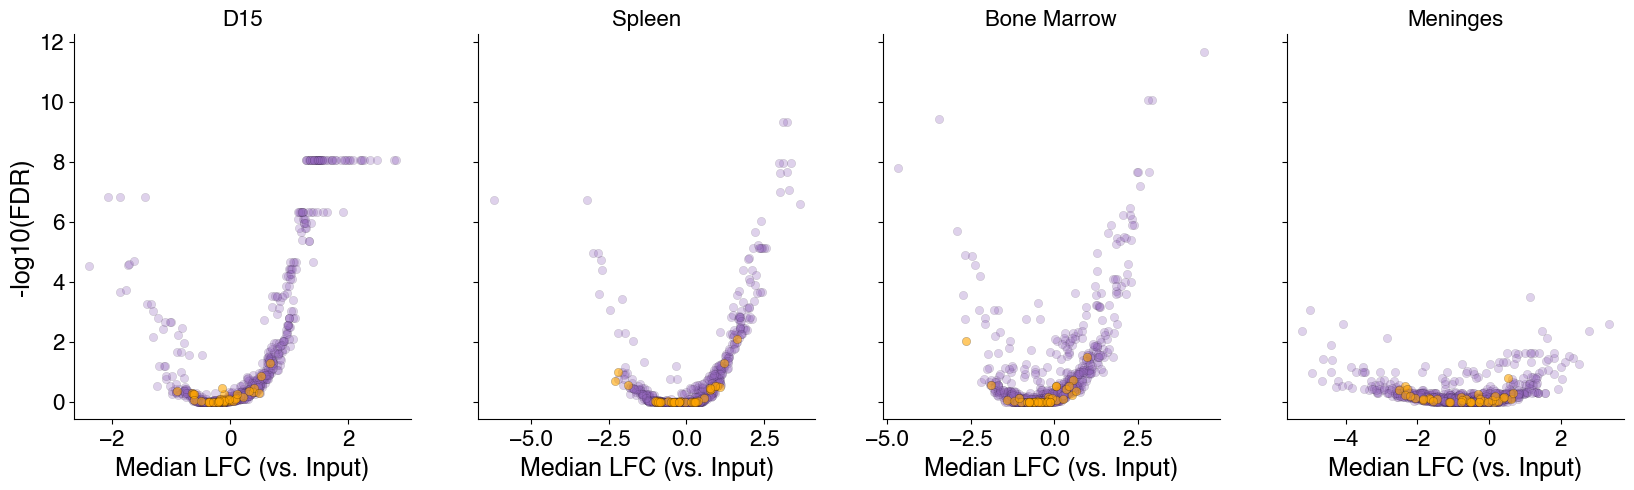

In [37]:
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(20,5), sharey=True)

for k, val in enumerate(names2):
    cc = ABE_targ
    cc[f'neglog10_FDR_{val}'] = -np.log10(
    cc[f'FDR_{val}_fishers'].clip(lower=1e-300)
)
    ax[k].scatter( cc[f'LFC_median_{val}'],cc[f'neglog10_FDR_{val}'],color='tab:purple', linewidth=.2, edgecolor='black', alpha=.3)

    cc2 = ABE_controls
    cc2[f'neglog10_FDR_{val}'] = -np.log10(
    cc2[f'FDR_{val}_fishers'].clip(lower=1e-300)
)
    ax[k].scatter( cc2[f'LFC_median_{val}'],cc2[f'neglog10_FDR_{val}'],color='orange', linewidth=.2, edgecolor='black', alpha=.6)
    ax[k].set_xlabel('Median LFC (vs. Input)', fontsize=18)
    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    # ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    # ax[k].set_xlabel('gRNA Rank', fontsize=16)

ax[0].set_ylabel('-log10(FDR)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

plt.savefig('figures/volcano_plot_ABE.pdf')

In [33]:
CBE_targ = CBE_LFC_FDR[(CBE_LFC_FDR['classification']=='targeting guide')]
CBE_controls = CBE_LFC_FDR[~(CBE_LFC_FDR['classification']=='targeting guide')]

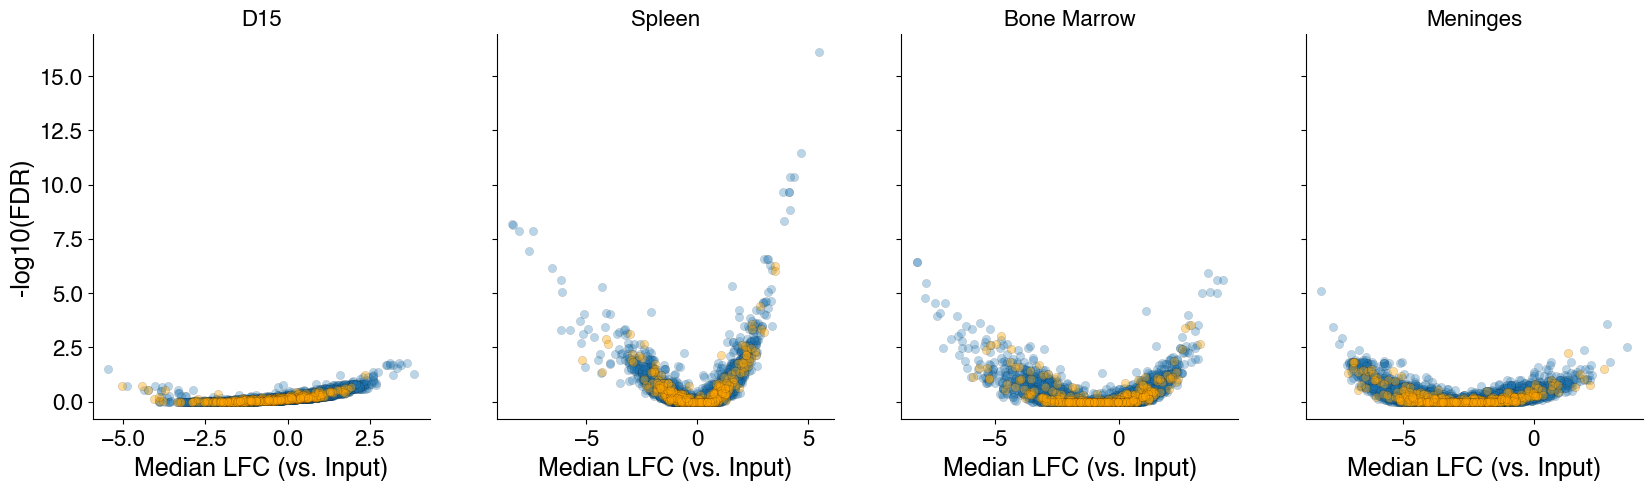

In [38]:
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(20,5), sharey=True)

for k, val in enumerate(names2):
    cc = CBE_targ
    cc[f'neglog10_FDR_{val}'] = -np.log10(
    cc[f'FDR_{val}_fishers'].clip(lower=1e-300)
)
    ax[k].scatter( cc[f'LFC_median_{val}'],cc[f'neglog10_FDR_{val}'],color='tab:blue', linewidth=.2, edgecolor='black', alpha=.3)

    cc2 = CBE_controls
    cc2[f'neglog10_FDR_{val}'] = -np.log10(
    cc2[f'FDR_{val}_fishers'].clip(lower=1e-300)
)
    ax[k].scatter( cc2[f'LFC_median_{val}'],cc2[f'neglog10_FDR_{val}'],color='orange', linewidth=.2, edgecolor='black', alpha=.4)
    ax[k].set_xlabel('Median LFC (vs. Input)', fontsize=18)
    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    # ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    # ax[k].set_xlabel('gRNA Rank', fontsize=16)

ax[0].set_ylabel('-log10(FDR)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

plt.savefig('figures/volcano_plot_CBE.pdf')

d15
1 Kmt2b R2717C tab:grey
2 Dnmt3a P800L tab:blue
3 Tcf7l2 P392S tab:red
4 Gata2 P175L tab:red
5 Foxp1 R465H tab:red
6 Fgf3 M190I tab:grey
7 Rab35 R69H tab:grey
8 Erg R309C tab:red
9 Crebbp R482Q tab:purple
10 Tek R167W tab:grey
8 Erg R309C tab:red
9 Crebbp R482Q tab:purple
10 Tek R167W tab:grey
12 Ptprs R925C tab:grey
13 Flt3 P937L tab:red
14 Carm1 R337W tab:grey
15 Kmt2d Q3632* tab:purple
16 Stag2 Q786* tab:blue
20 Kmt2d S2130L tab:purple
29 Eif4e R112Q tab:grey
1. Kmt2b R2717C
2. Dnmt3a P800L
3. Tcf7l2 P392S
4. Gata2 P175L
5. Foxp1 R465H
6. Fgf3 M190I
7. Rab35 R69H
8. Erg R309C
9. Crebbp R482Q
10. Tek R167W
spleen
1 Tek R167W tab:grey
2 Flt4 p.G1154R (H) tab:red
3 Zfhx3 A3330T tab:blue
4 Gnas R1004C tab:red
5 Brd4 E1160K tab:red
6 Keap1 R413C tab:blue
7 Cul3 R761C tab:blue
8 Card11 R888C tab:red
9 Card11 R967C tab:red
10 Ptprt E831K tab:blue
8278 Myod1 R120H tab:red
8279 Med12 R1497C tab:blue
8280 Pim1 E246K tab:red
8281 Atm E2454K tab:blue
8282 Ikzf1 p.R208* (H) tab:blue
8283 Sma

Text(0.5, 1.0, 'Meninges')

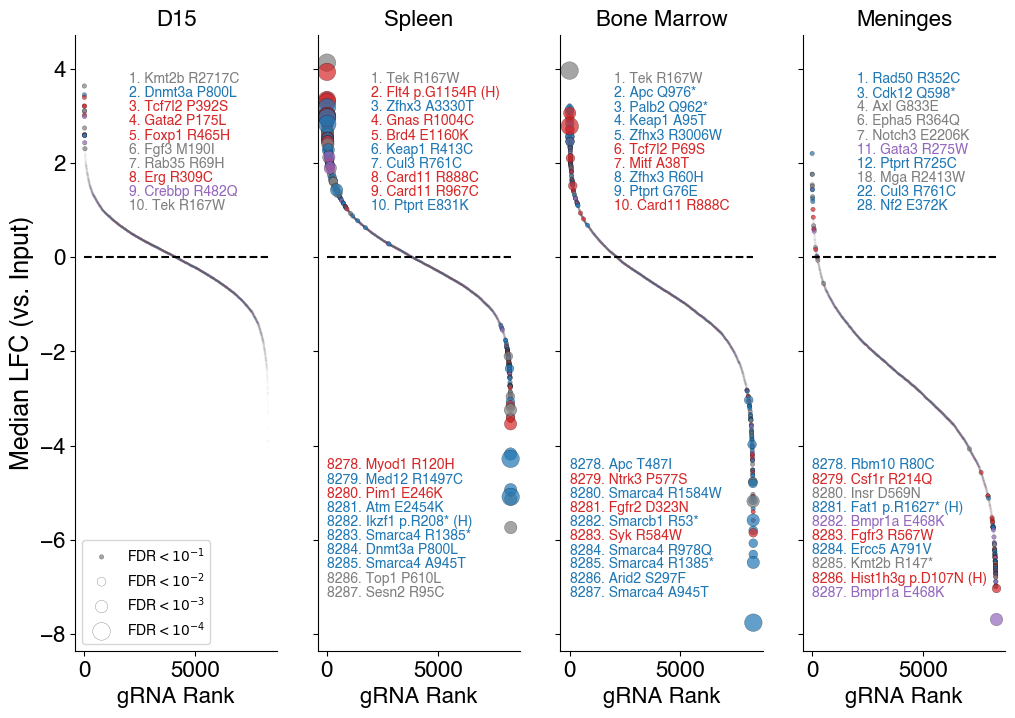

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects

min_edit = 20
FDR_cutoff = .1
min_input_counts = 2

CBE_targ = CBE_LFC_FDR[(CBE_LFC_FDR['classification']=='targeting guide')& (CBE_LFC_FDR['target_base_edit_perc']>=min_edit) & (CBE_LFC_FDR['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]

color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]



    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) &(cc2[f'FDR_{val}']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}']<FDR_cutoff]
    top = cc3[:10]
    bottom = cc3[-10:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (H)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')

    #top
    #specific modifications for CBE
    if k==0:
        for idx, j in enumerate(ns[:10]):
            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')

    elif k==3:
        for idx, j in enumerate(ns[:10]):
            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')

    else: 
        for idx, j in enumerate(ns[:10]):

            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')

    for idx, j in enumerate(ns[10:]):
        if k==0:
            continue
            #ax[k].text(10,-1.5 -(idx*.3), j, color=c[idx+10])
            #print(f'{j}')
        else:
            ax[k].text(10,-4.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')


    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

#fig.savefig('figures/2h_UPDATED.png', dpi=300, transparent=True)

# Volcano Plots — OG ABE & CBE (Empirical vs MAGeCK)

Two versions: with 20% editing cut-off and without. Controls shown as grey points with black outline. Left column = Empirical FDR; Right column = MAGeCK FDR.

In [58]:
# ── Load MAGeCK sgrna summaries ───────────────────────────────────────────
MAGECK_DIR = '/Users/kexindong/Documents/GitHub/SG-B-ALL-in-vivo-base-editing/mageck/sgrna_summaries'

conditions = ['d15', 'spleen', 'bonemarrow', 'meninges']

ABE_mageck = {}
CBE_mageck = {}
for cond in conditions:
    ABE_mageck[cond] = pd.read_csv(f'{MAGECK_DIR}/ABE_{cond}_input.sgrna_summary.txt', sep='\t').rename(columns={'sgrna': 'gRNA_id'})
    CBE_mageck[cond] = pd.read_csv(f'{MAGECK_DIR}/CBE_{cond}_input.sgrna_summary.txt', sep='\t').rename(columns={'sgrna': 'gRNA_id'})


In [59]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':     pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':     pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC': {'bm':    ['bm1','bm3','bm5'],
                   'spleen':['spleen1','spleen3'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':  {'bm':    ['bm1','bm3','bm5'],
                   'spleen':['spleen1','spleen3'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':  {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                   'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')

Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides


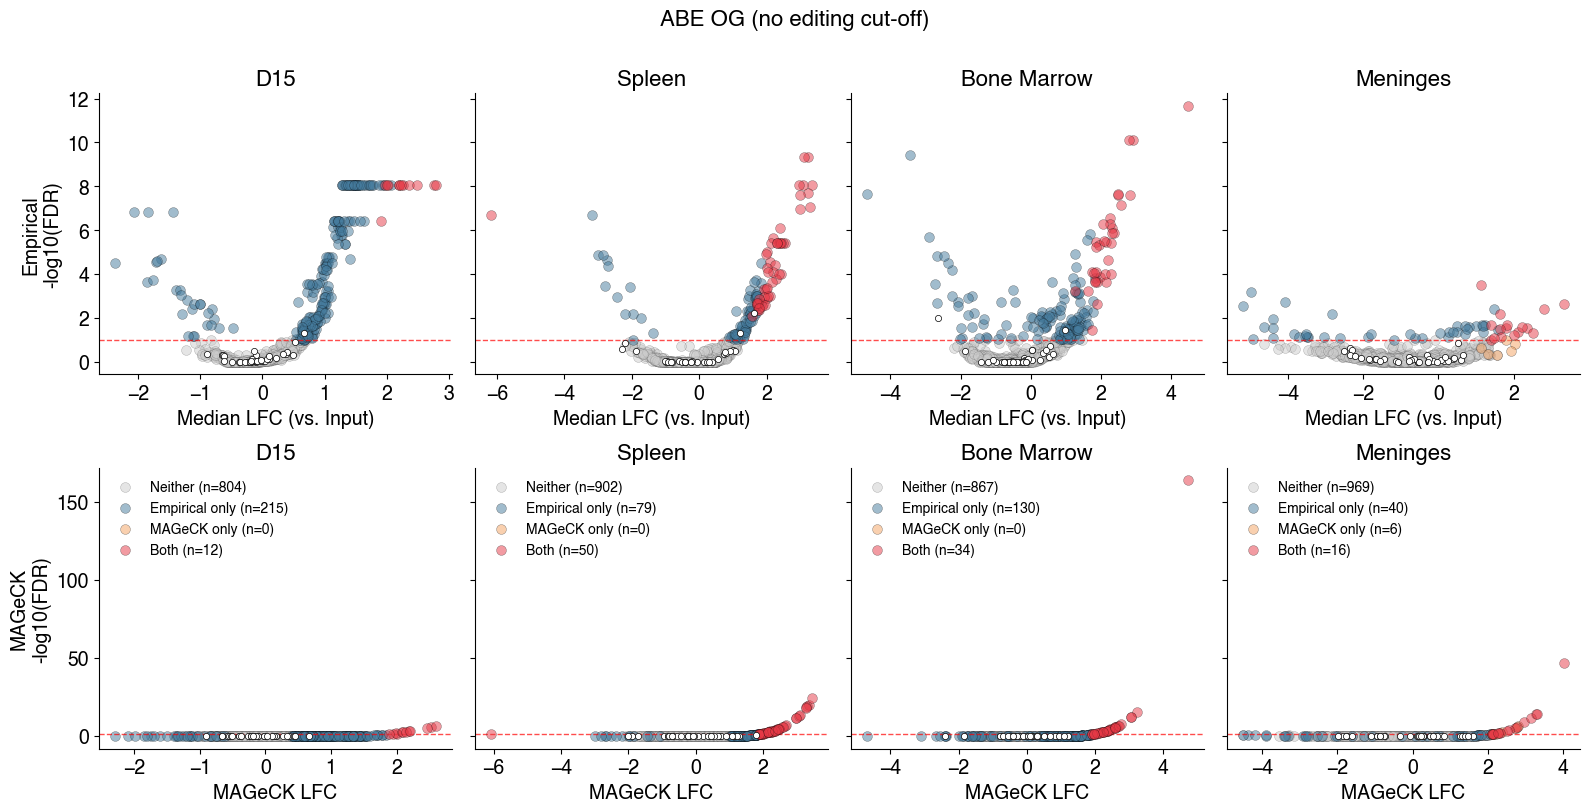

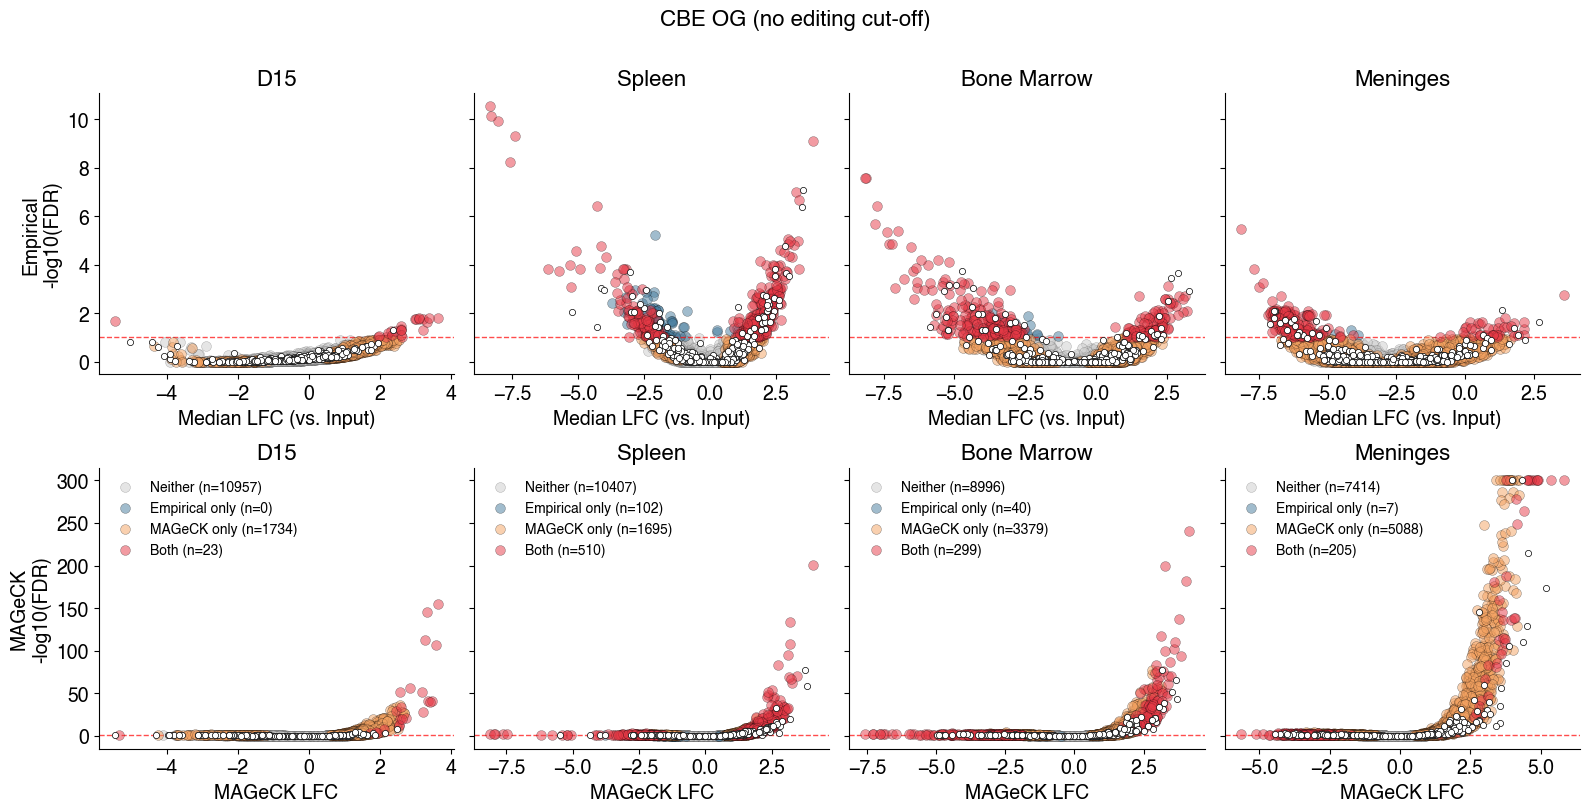

In [89]:
# ── Volcano plots — OG ABE & CBE, ≥20% editing ──────────────────────────
# Color: Both hit / MAGeCK-only / Empirical-only / neither / controls (grey)
conditions_emp = ['d15', 'spleen', 'bm',          'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow',   'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow',  'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 5

# hit-category colors
cat_colors = {
    'Both':          '#e63946',
    'MAGeCK only':   '#f4a261',
    'Empirical only':'#457b9d',
    'Neither':       '#cccccc',
}
for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck), ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    ctrl_emp = df_emp[df_emp['classification'] != 'targeting guide'].copy()
    targ_emp = df_emp[
        (df_emp['classification'] == 'targeting guide') &
        # editing threshold
        # (df_emp['target_base_edit_perc_d5'] >= 20) &
        (df_emp['Input_median'] >= min_input_counts)
    ].copy()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey='row')

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'
        emp_lfc_col = f'LFC_median_{emp_cond}'

        # merge empirical targets with MAGeCK FDR
        mag = mag_dict[mag_cond][['gRNA_id', 'LFC', 'FDR']].rename(columns={'LFC': 'mag_LFC', 'FDR': 'mag_FDR'})
        merged = pd.merge(targ_emp[['gRNA_id', emp_lfc_col, emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hit = merged[emp_fdr_col] < FDR_cutoff
        mag_hit = merged['mag_FDR']   < FDR_cutoff
        merged['category'] = 'Neither'
        merged.loc[emp_hit & ~mag_hit, 'category'] = 'Empirical only'
        merged.loc[~emp_hit & mag_hit, 'category'] = 'MAGeCK only'
        merged.loc[emp_hit & mag_hit,  'category'] = 'Both'

        # also compute empirical nlog10 for controls
        ctrl_emp[f'nlog10_{emp_cond}'] = -np.log10(ctrl_emp[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_emp'] = -np.log10(merged[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_mag'] = -np.log10(merged['mag_FDR'].clip(lower=1e-300))

        for row_idx, (ax, y_col, x_col, ylabel) in enumerate([
            (axes[0][k], 'nlog10_emp', emp_lfc_col, 'Empirical\n-log10(FDR)'),
            (axes[1][k], 'nlog10_mag', 'mag_LFC',   'MAGeCK\n-log10(FDR)'),
        ]):
            # plot in order: Neither first, then singles, then Both on top
            for cat in ['Neither', 'Empirical only', 'MAGeCK only', 'Both']:
                sub = merged[merged['category'] == cat]
                ax.scatter(sub[x_col], sub[y_col],
                           color=cat_colors[cat], edgecolor='black' if cat != 'Neither' else greys[4],
                           linewidth=0.3, s=50,
                           alpha=0.5,
                           zorder=1 if cat == 'Neither' else 2 + ['Empirical only','MAGeCK only','Both'].index(cat),
                           label=f'{cat} (n={len(sub)})')
        #    controls
            if row_idx == 0:
                ax.scatter(ctrl_emp[emp_lfc_col], ctrl_emp[f'nlog10_{emp_cond}'],
                           color='white', edgecolor='black', linewidth=.5, s=20, alpha=1, zorder=6)
            else:
                ctrl_mag = pd.merge(ctrl_emp[['gRNA_id', emp_lfc_col]], mag, on='gRNA_id', how='inner')
                ctrl_mag['nlog10_mag'] = -np.log10(ctrl_mag['mag_FDR'].clip(lower=1e-300))
                ax.scatter(ctrl_mag['mag_LFC'], ctrl_mag['nlog10_mag'],
                           color='white', edgecolor='black', linewidth=.5, s=20, alpha=1, zorder=6)

            ax.axhline(-np.log10(FDR_cutoff), color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.set_title(title, fontsize=16)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.set_xlabel('Median LFC (vs. Input)' if row_idx == 0 else 'MAGeCK LFC', fontsize=14)
            if k == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if row_idx == 1:
                ax.legend(fontsize=10, frameon=False, loc='upper left')

    fig.suptitle(f'{editor} OG (no editing cut-off)', fontsize=16, y=1.01)
    fig.tight_layout()
    plt.savefig(f'figures_final/volcano_comparison_{editor}_OG_no_editing_cut.png', bbox_inches='tight', dpi=600)
    plt.show()

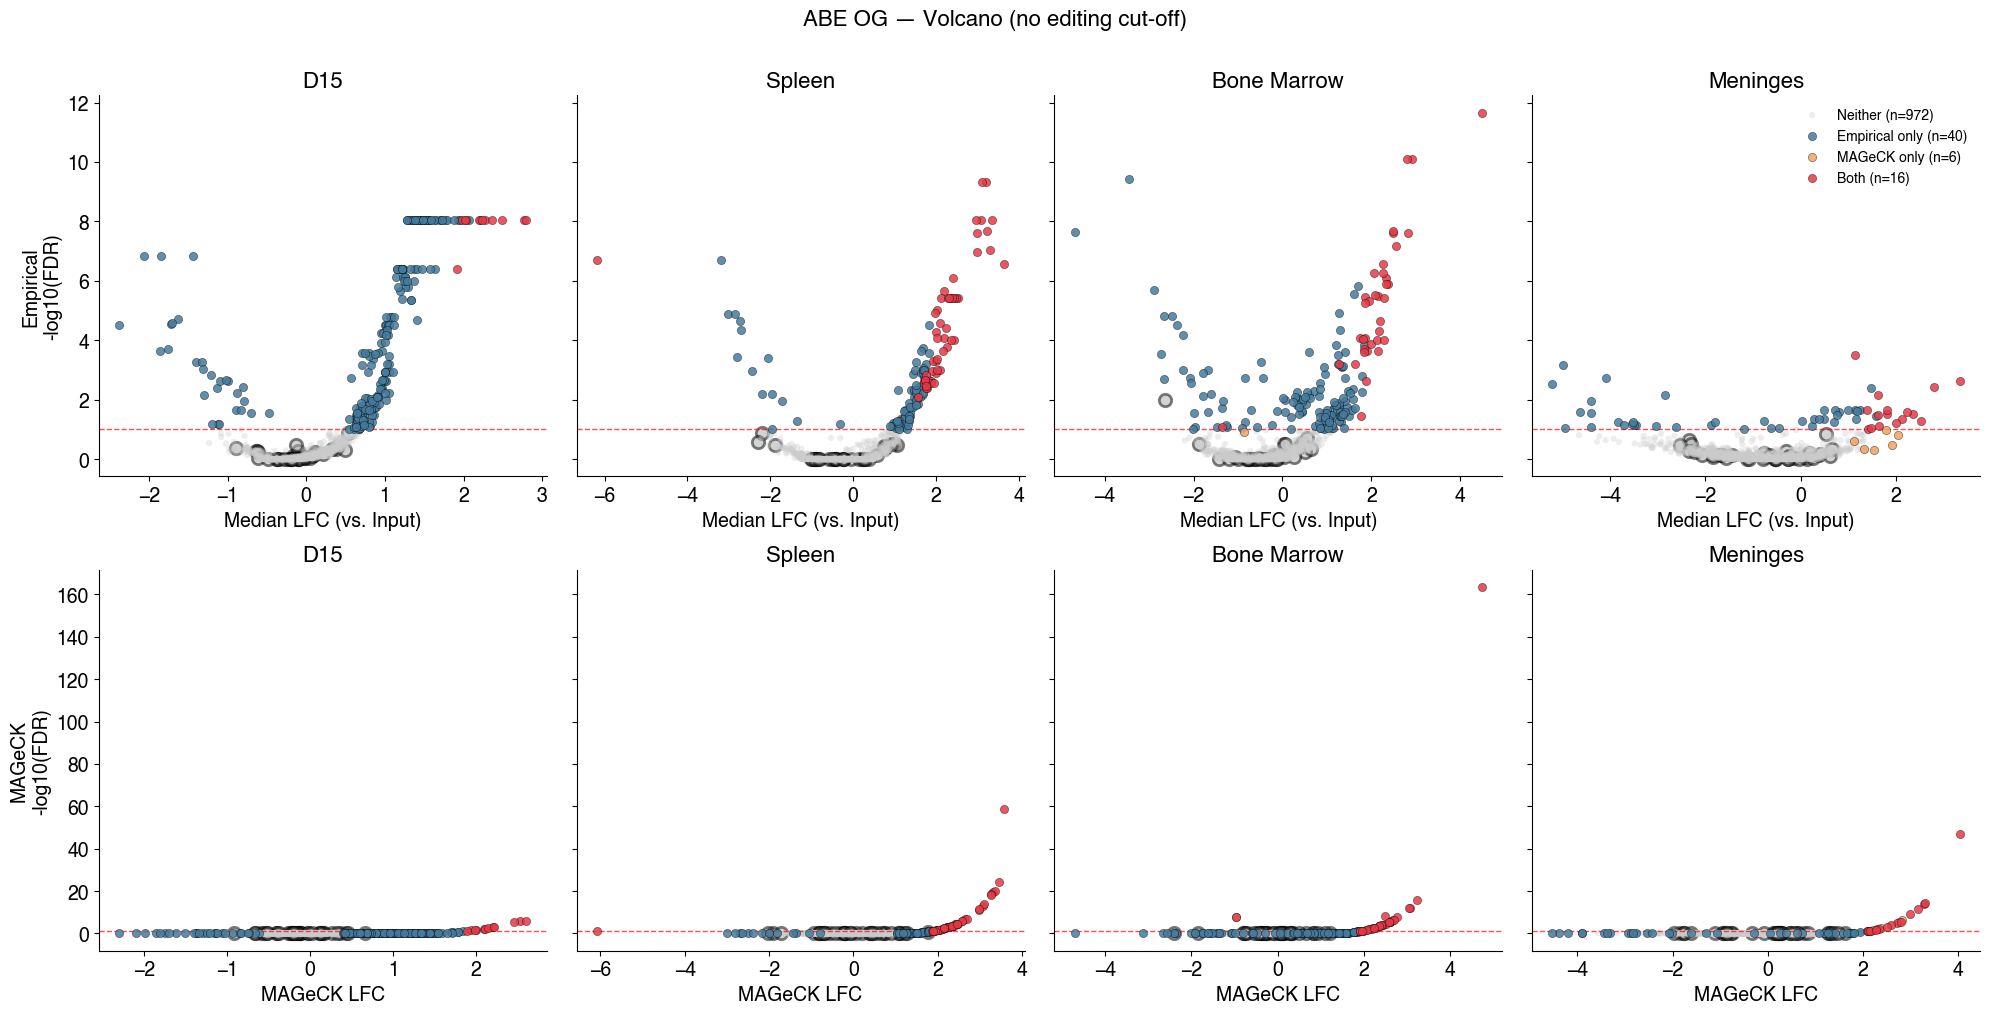

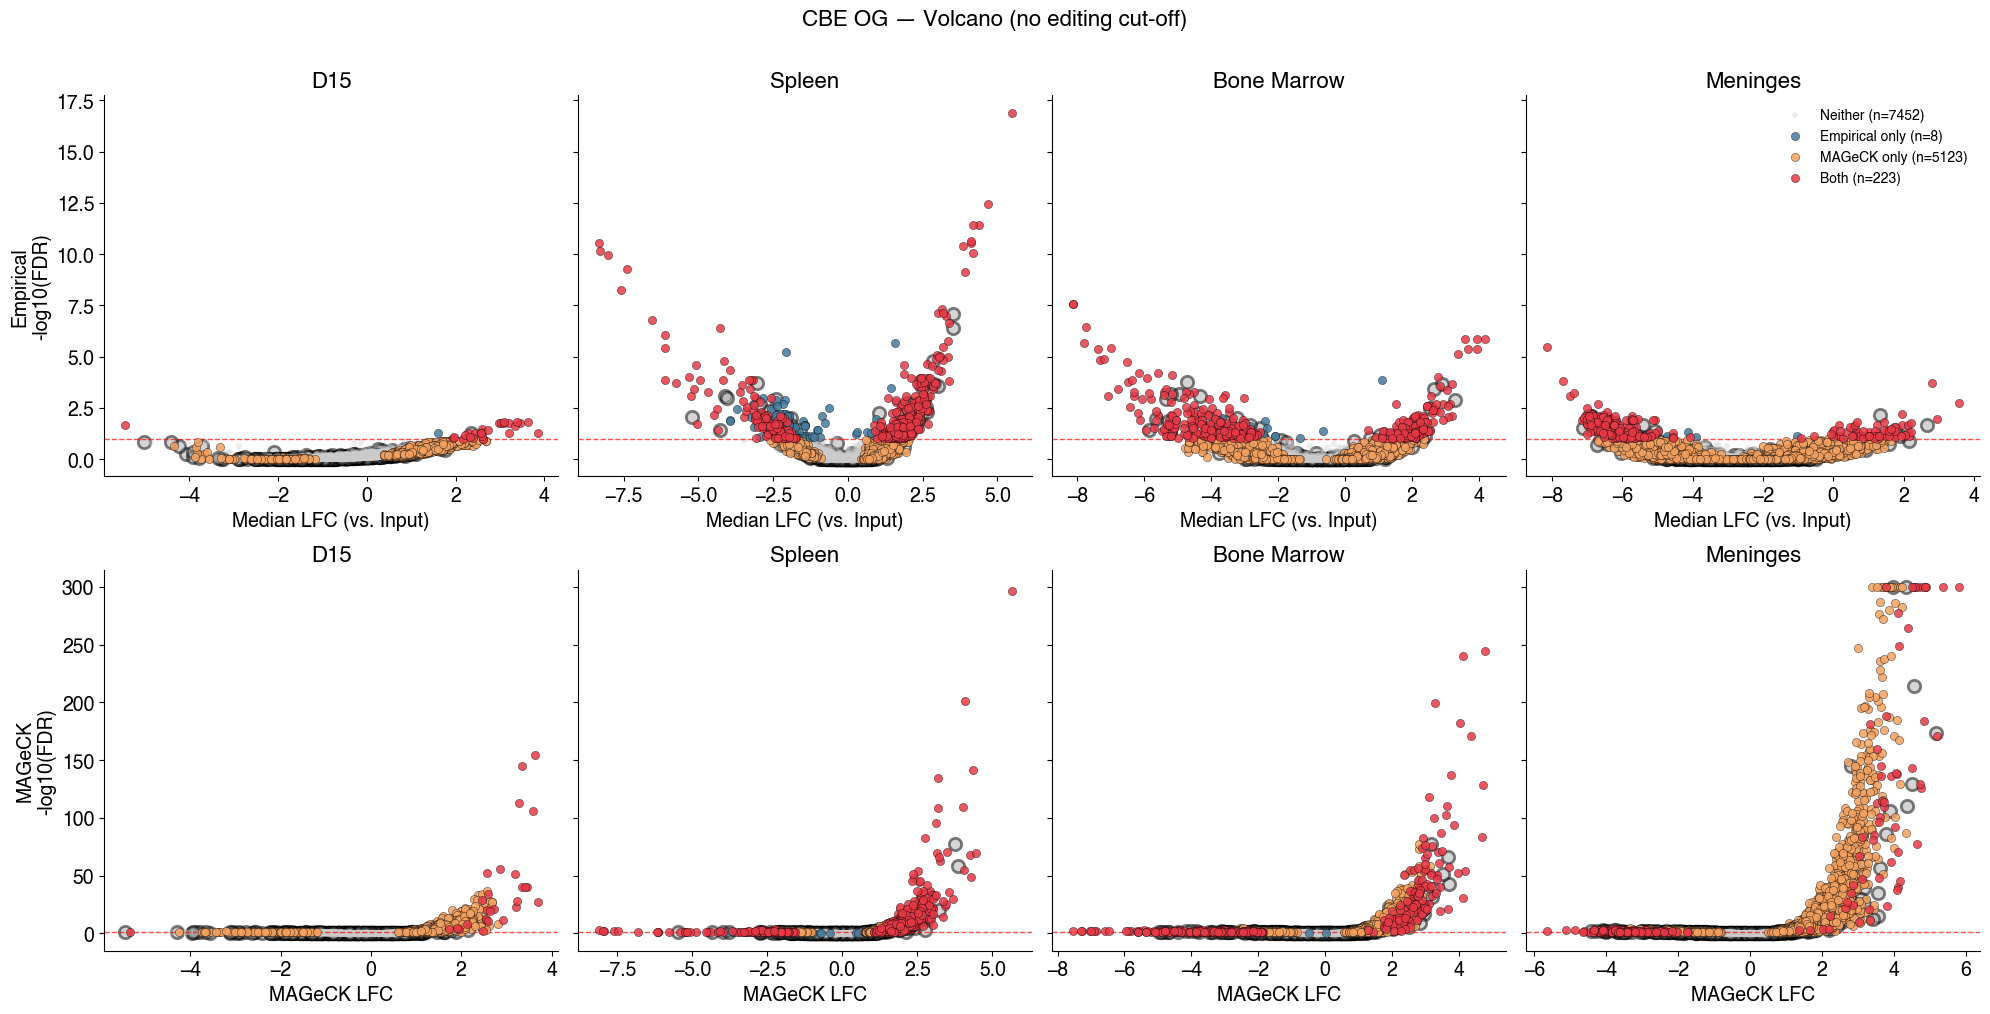

In [82]:
# ── Volcano plots — OG ABE & CBE, no editing cut-off ──────────────────────────
# Color: Both hit / MAGeCK-only / Empirical-only / neither / controls (grey)

conditions_emp = ['d15', 'spleen', 'bm',          'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow',   'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow',  'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 2

# hit-category colors
cat_colors = {
    'Both':          '#e63946',
    'MAGeCK only':   '#f4a261',
    'Empirical only':'#457b9d',
    'Neither':       '#cccccc',
}

for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck), ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    ctrl_emp = df_emp[df_emp['classification'] != 'targeting guide'].copy()
    targ_emp = df_emp[df_emp['classification'] == 'targeting guide'].copy()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey='row')

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'
        emp_lfc_col = f'LFC_median_{emp_cond}'

        # merge empirical targets with MAGeCK FDR
        mag = mag_dict[mag_cond][['gRNA_id', 'LFC', 'FDR']].rename(columns={'LFC': 'mag_LFC', 'FDR': 'mag_FDR'})
        merged = pd.merge(targ_emp[['gRNA_id', emp_lfc_col, emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hit = merged[emp_fdr_col] < FDR_cutoff
        mag_hit = merged['mag_FDR']   < FDR_cutoff
        merged['category'] = 'Neither'
        merged.loc[emp_hit & ~mag_hit, 'category'] = 'Empirical only'
        merged.loc[~emp_hit & mag_hit, 'category'] = 'MAGeCK only'
        merged.loc[emp_hit & mag_hit,  'category'] = 'Both'

        # also compute empirical nlog10 for controls
        ctrl_emp[f'nlog10_{emp_cond}'] = -np.log10(ctrl_emp[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_emp'] = -np.log10(merged[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_mag'] = -np.log10(merged['mag_FDR'].clip(lower=1e-300))

        for row_idx, (ax, y_col, x_col, ylabel) in enumerate([
            (axes[0][k], 'nlog10_emp', emp_lfc_col, 'Empirical\n-log10(FDR)'),
            (axes[1][k], 'nlog10_mag', 'mag_LFC',   'MAGeCK\n-log10(FDR)'),
        ]):
            # controls
            if row_idx == 0:
                ax.scatter(ctrl_emp[emp_lfc_col], ctrl_emp[f'nlog10_{emp_cond}'],
                           color='#aaaaaa', edgecolor='black', linewidth=2, s=80, alpha=0.5, zorder=1)
            else:
                ctrl_mag = pd.merge(ctrl_emp[['gRNA_id', emp_lfc_col]], mag, on='gRNA_id', how='inner')
                ctrl_mag['nlog10_mag'] = -np.log10(ctrl_mag['mag_FDR'].clip(lower=1e-300))
                ax.scatter(ctrl_mag['mag_LFC'], ctrl_mag['nlog10_mag'],
                           color='#aaaaaa', edgecolor='black', linewidth=2, s=80, alpha=0.5, zorder=1)

            # plot in order: Neither first, then singles, then Both on top
            for cat in ['Neither', 'Empirical only', 'MAGeCK only', 'Both']:
                sub = merged[merged['category'] == cat]
                ax.scatter(sub[x_col], sub[y_col],
                           color=cat_colors[cat], edgecolor='black' if cat != 'Neither' else 'none',
                           linewidth=0.3, s=20 if cat == 'Neither' else 35,
                           alpha=0.35 if cat == 'Neither' else 0.85,
                           zorder=2 if cat == 'Neither' else 3 + ['Empirical only','MAGeCK only','Both'].index(cat),
                           label=f'{cat} (n={len(sub)})')

            ax.axhline(-np.log10(FDR_cutoff), color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.set_title(title, fontsize=16)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.set_xlabel('Median LFC (vs. Input)' if row_idx == 0 else 'MAGeCK LFC', fontsize=14)
            if k == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if k == 3 and row_idx == 0:
                ax.legend(fontsize=10, frameon=False, loc='upper right')

    fig.suptitle(f'{editor} OG — Volcano (no editing cut-off)', fontsize=16, y=1.01)
    fig.tight_layout()
    plt.show()


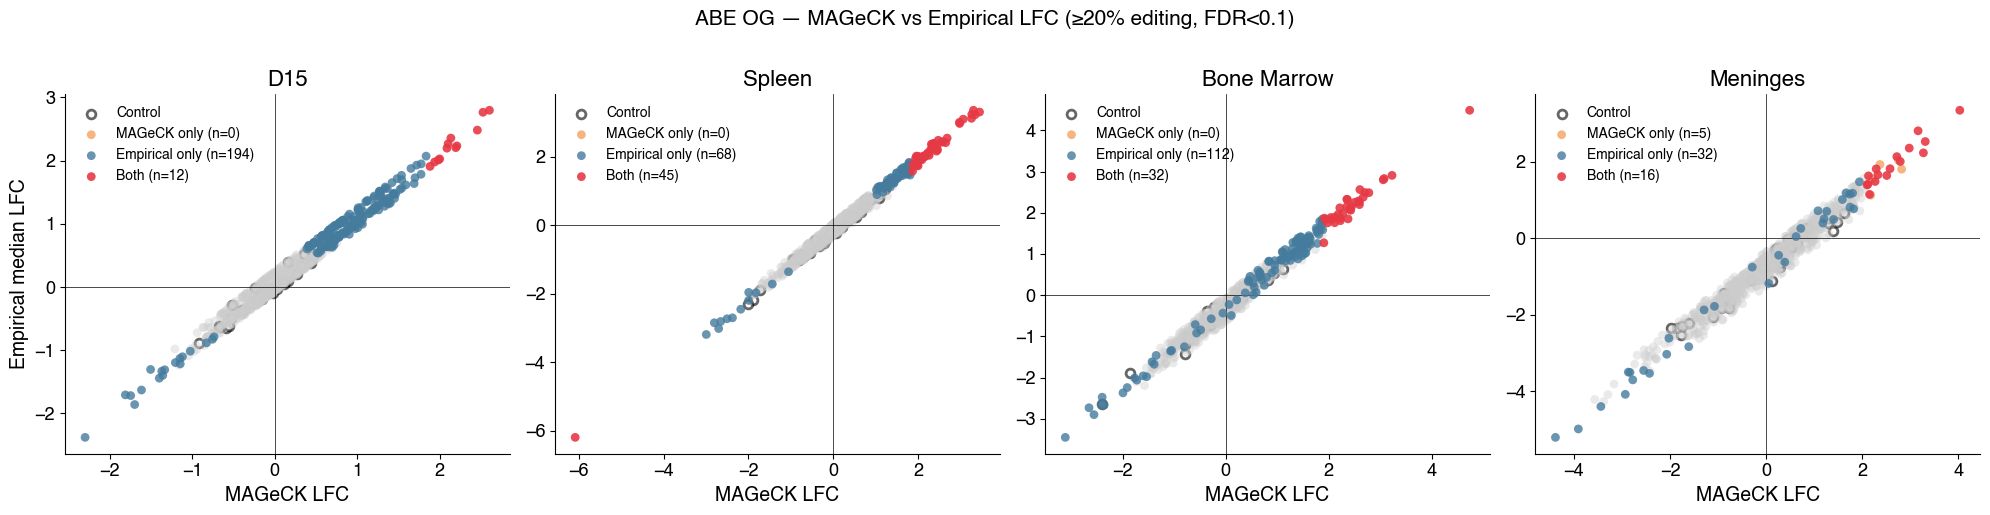

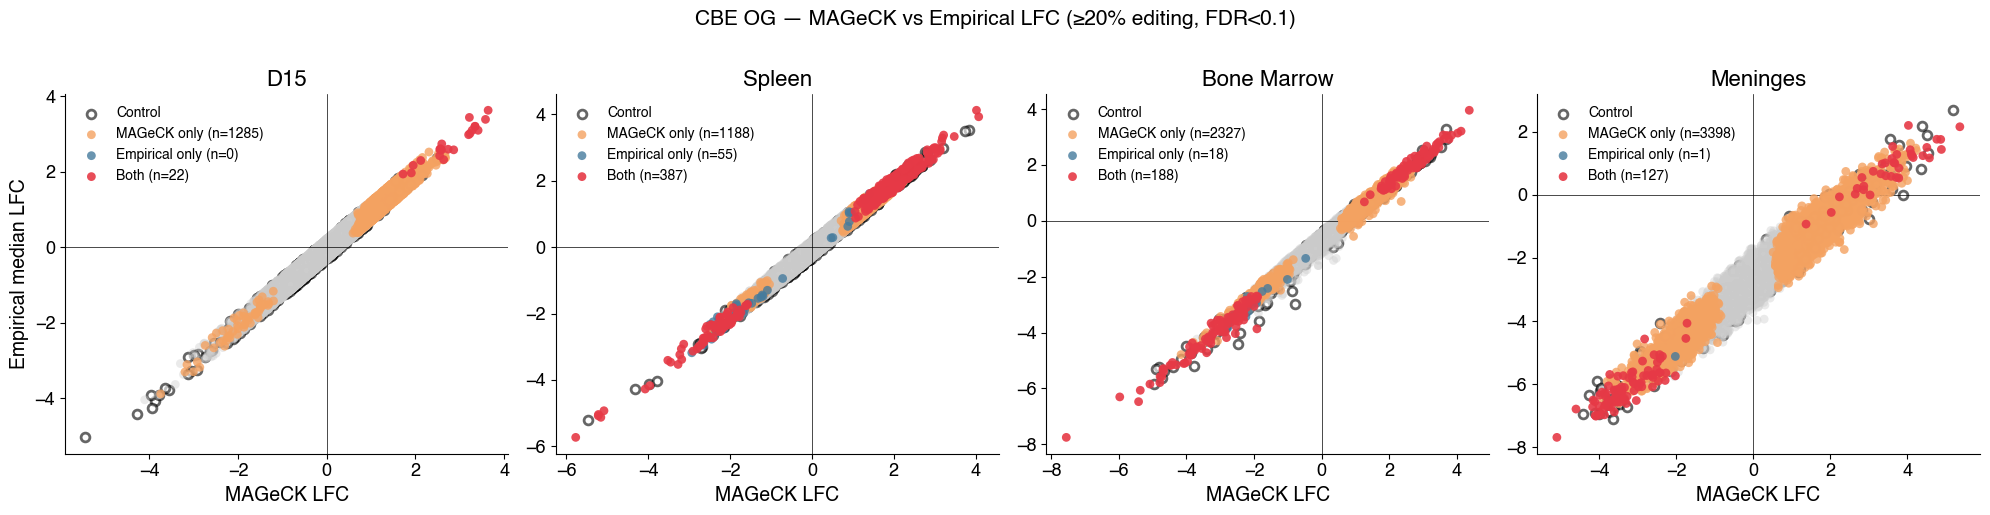

In [83]:
# ── MAGeCK vs Empirical LFC scatter — OG ABE & CBE ───────────────────────
# x = MAGeCK LFC, y = Empirical median LFC
# Color: both-hit / MAGeCK-only / Empirical-only / neither; controls = white outline

FDR_cutoff       = 0.1
min_edit         = 20
min_input_counts = 2

conditions_emp = ['d15', 'spleen', 'bm',        'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow', 'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow', 'Meninges']

for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck), ('CBE', dfs['CBE_OG'], CBE_mageck)]:

    targ_eligible = df_emp[
        (df_emp['classification'] == 'targeting guide') &
        (df_emp['target_base_edit_perc_d5'] >= min_edit) &
        (df_emp['Input_median'] >= min_input_counts)
    ]
    ctrl = df_emp[df_emp['classification'] != 'targeting guide']

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        ax = axes[k]
        emp_fdr_col = f'FDR_{emp_cond}_fishers'
        emp_lfc_col = f'LFC_median_{emp_cond}'

        mag = mag_dict[mag_cond][['gRNA_id', 'LFC', 'FDR']].rename(
            columns={'LFC': 'mag_LFC', 'FDR': 'mag_FDR'})
        merged = pd.merge(
            targ_eligible[['gRNA_id', emp_lfc_col, emp_fdr_col, 'gene_name_m_corrected', 'Role in Cancer']],
            mag, on='gRNA_id', how='inner')

        emp_hit = merged[emp_fdr_col] < FDR_cutoff
        mag_hit = merged['mag_FDR']   < FDR_cutoff
        both     = emp_hit & mag_hit
        emp_only = emp_hit & ~mag_hit
        mag_only = ~emp_hit & mag_hit
        neither  = ~emp_hit & ~mag_hit

        ctrl_mag = pd.merge(ctrl[['gRNA_id', emp_lfc_col]], mag, on='gRNA_id', how='inner')
        ax.scatter(ctrl_mag['mag_LFC'], ctrl_mag[emp_lfc_col],
                   facecolor='white', edgecolor='black', linewidth=2, s=40, alpha=0.6, zorder=1, label='Control')
        ax.scatter(merged.loc[neither,  'mag_LFC'], merged.loc[neither,  emp_lfc_col],
                   color='#cccccc', edgecolor='none', s=40, alpha=0.4, zorder=2)
        ax.scatter(merged.loc[mag_only, 'mag_LFC'], merged.loc[mag_only, emp_lfc_col],
                   color='#f4a261', edgecolor='none', linewidth=0.3, s=40, alpha=0.8, zorder=3,
                   label=f'MAGeCK only (n={mag_only.sum()})')
        ax.scatter(merged.loc[emp_only, 'mag_LFC'], merged.loc[emp_only, emp_lfc_col],
                   color='#457b9d', edgecolor='none', linewidth=0.3, s=40, alpha=0.8, zorder=3,
                   label=f'Empirical only (n={emp_only.sum()})')
        ax.scatter(merged.loc[both,     'mag_LFC'], merged.loc[both,     emp_lfc_col],
                   color='#e63946', edgecolor='none', linewidth=0.3, s=40, alpha=0.9, zorder=4,
                   label=f'Both (n={both.sum()})')

        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlabel('MAGeCK LFC', fontsize=14)
        ax.set_title(title, fontsize=16)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13)
        if k == 0:
            ax.set_ylabel('Empirical median LFC', fontsize=14)
        ax.legend(fontsize=10, frameon=False, loc='upper left')

    fig.suptitle(f'{editor} OG — MAGeCK vs Empirical LFC (≥20% editing, FDR<0.1)', fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
